In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h 
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pt100_acid.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.43,7
,3000,0,0.49,7
,3000,0,0.51,31


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   774.02    41.22
p_loo       11.86        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



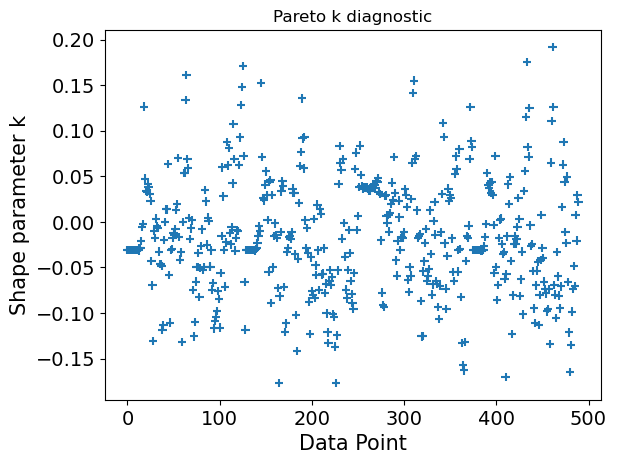

In [2]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.074  0.003  -0.080   -0.068      0.000    0.000     934.0    1395.0   1.01
deltaG4_0   0.911  0.003   0.906    0.917      0.000    0.000    1011.0    1417.0   1.00
Gact2_0     0.688  0.001   0.686    0.691      0.000    0.000    1266.0    1487.0   1.01
sigma_rel   0.400  0.039   0.331    0.474      0.001    0.001    1406.0    1846.0   1.00
sigma_base  0.007  0.001   0.006    0.008      0.000    0.000    3052.0    2416.0   1.00
exponent    1.597  0.095   1.424    1.781      0.003    0.002    1322.0    1677.0   1.00


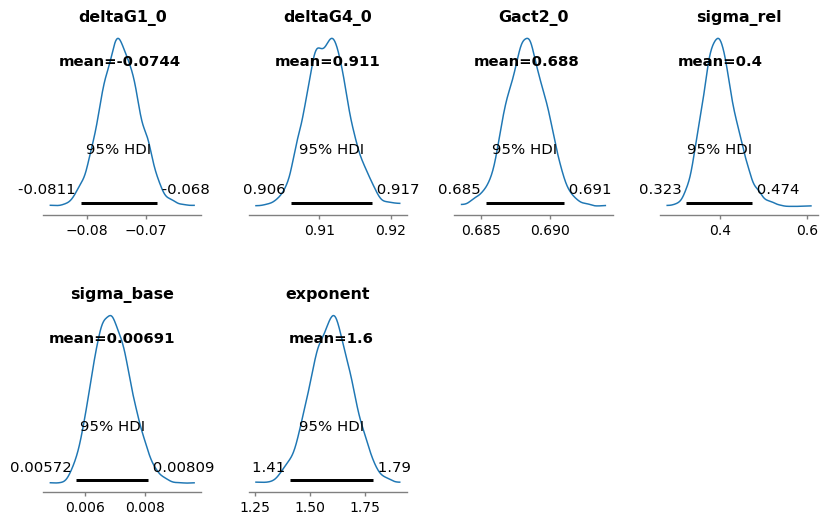

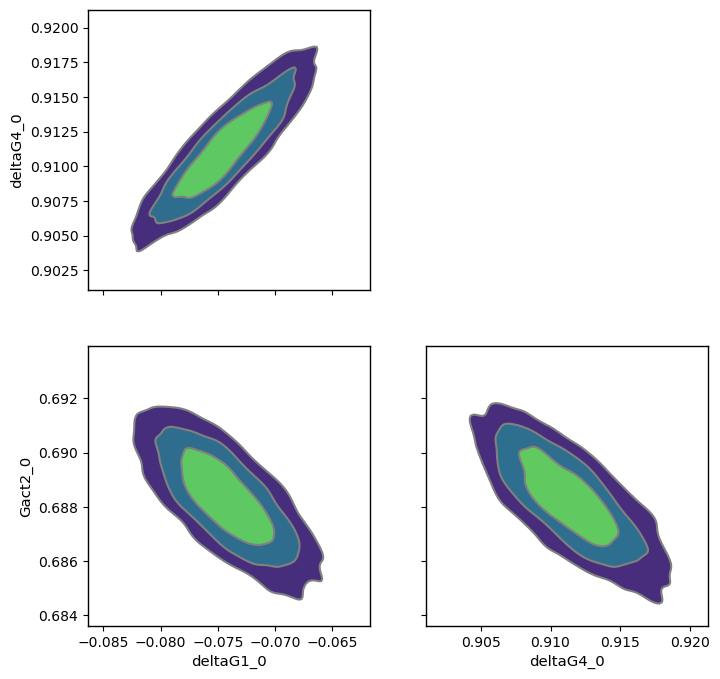

Sampling: [rate]


rate: 0.612


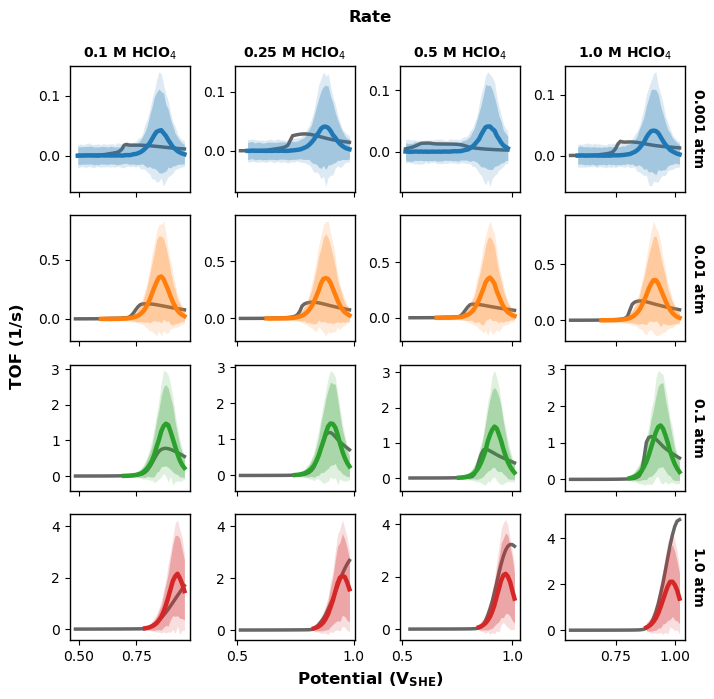

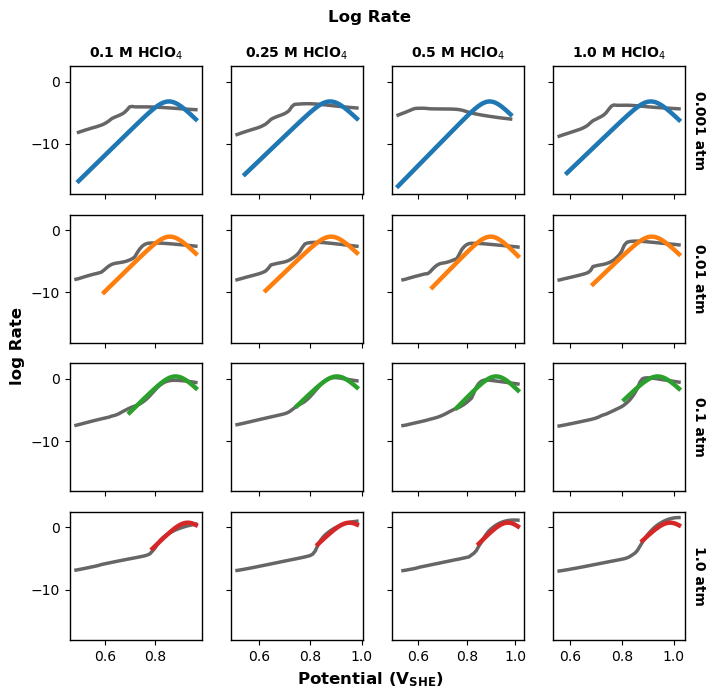

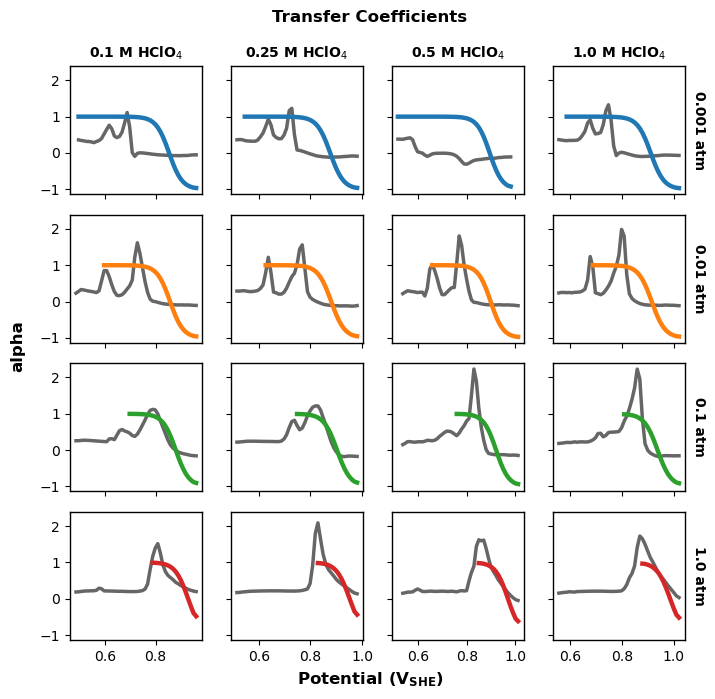

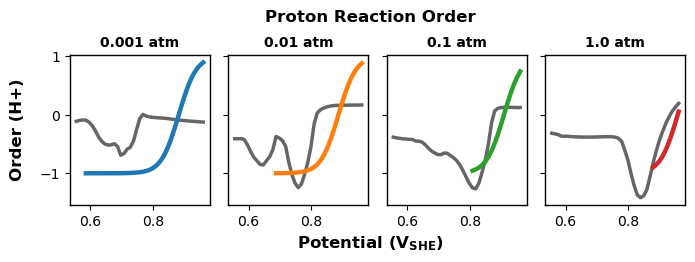

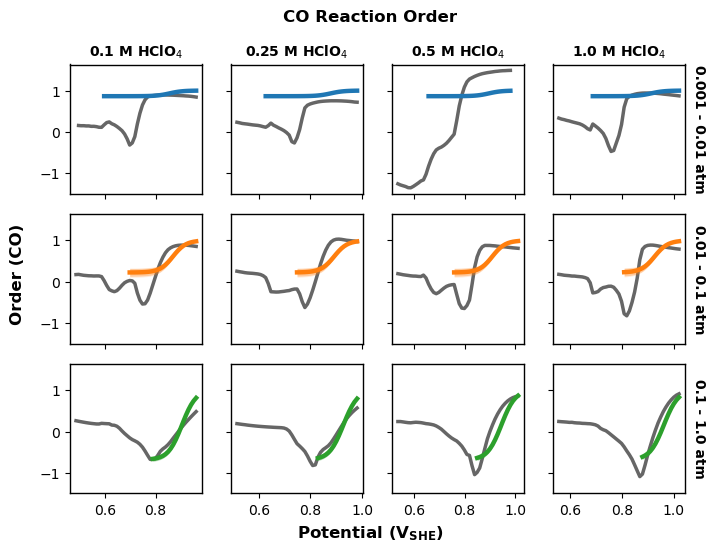

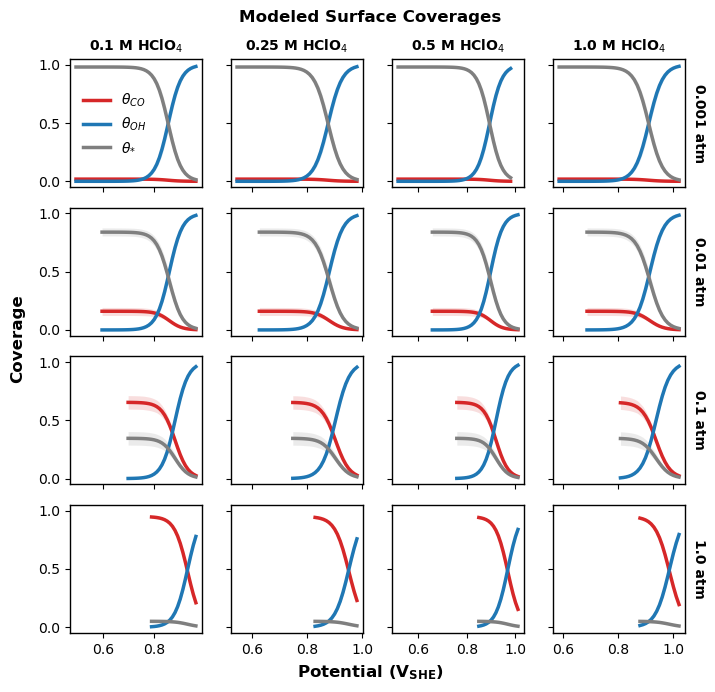

In [3]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.17,63
,3000,0,0.16,15
,3000,0,0.18,31
,3000,0,0.17,127


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   861.30    42.34
p_loo       11.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



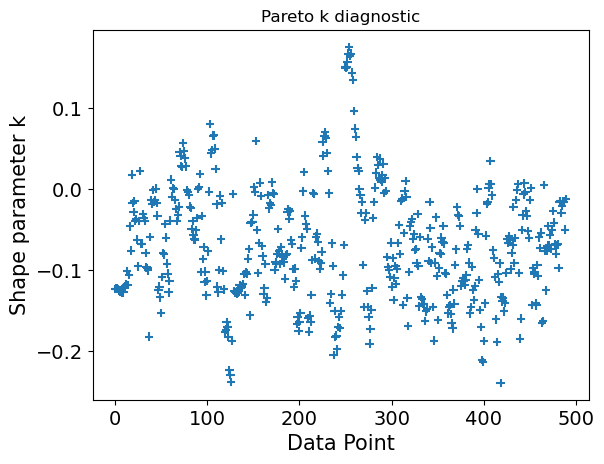

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.161  0.009  -0.178   -0.142      0.000    0.000     714.0    1236.0   1.00
deltaG4_0   0.848  0.011   0.829    0.869      0.000    0.000     620.0    1060.0   1.00
Gact2_0     1.250  0.014   1.225    1.277      0.001    0.000     515.0     716.0   1.01
beta_2      0.559  0.016   0.528    0.587      0.001    0.000     520.0     747.0   1.01
sigma_rel   0.367  0.034   0.304    0.432      0.001    0.001    2529.0    2368.0   1.00
sigma_base  0.003  0.001   0.002    0.004      0.000    0.000    3280.0    3065.0   1.00
exponent    1.692  0.071   1.549    1.814      0.001    0.001    2534.0    2504.0   1.00


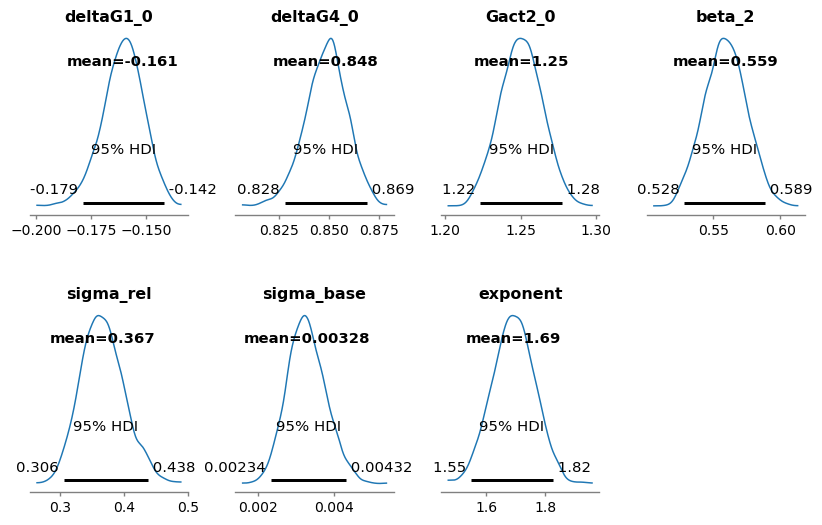

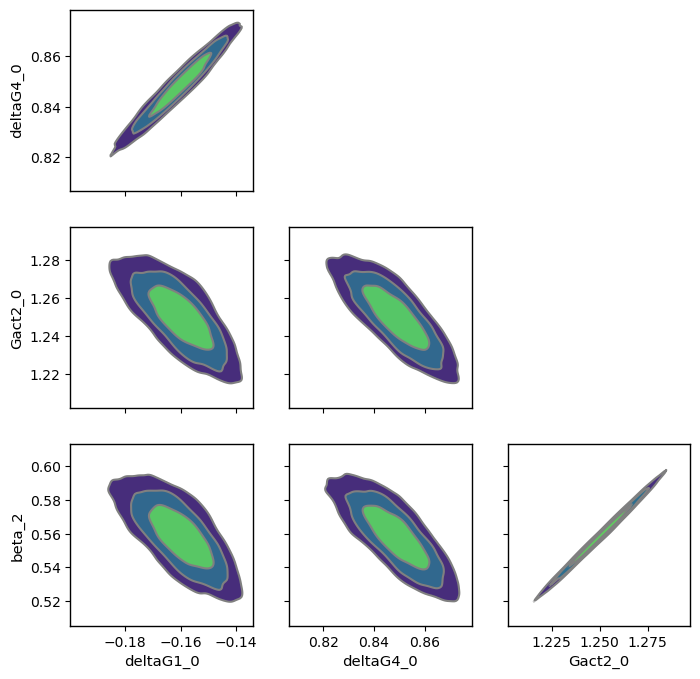

Sampling: [rate]


rate: 0.806


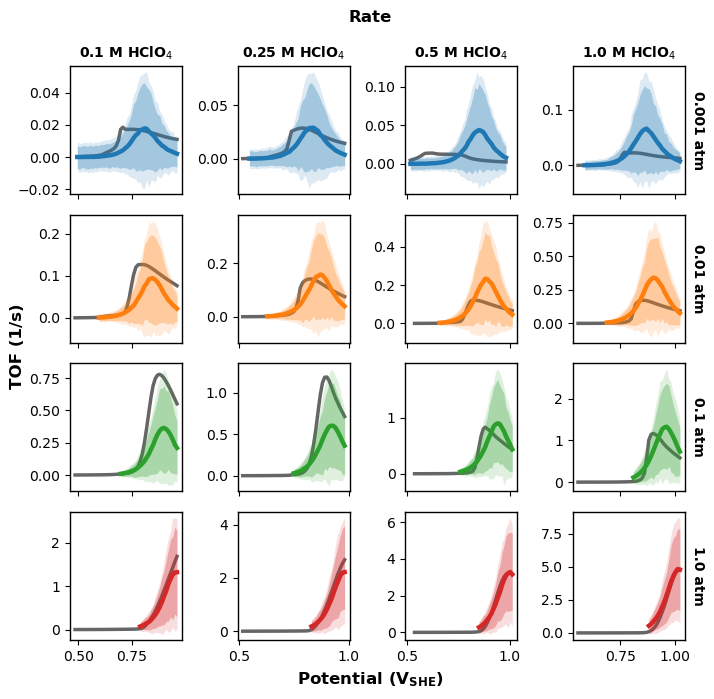

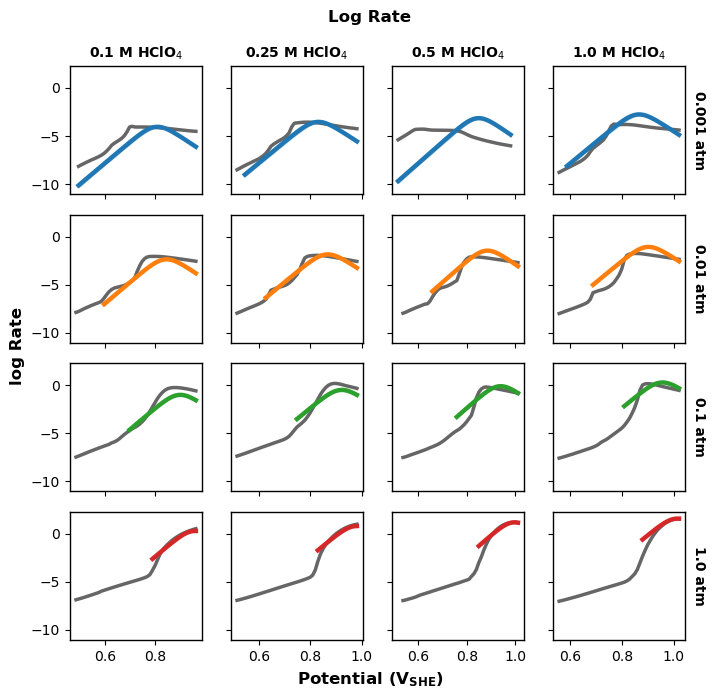

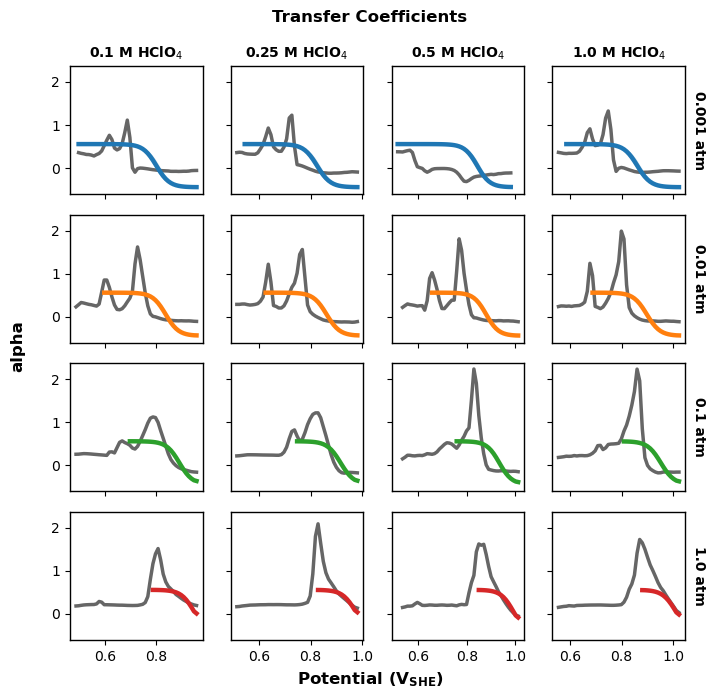

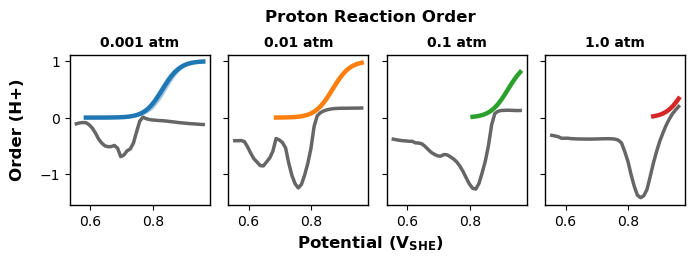

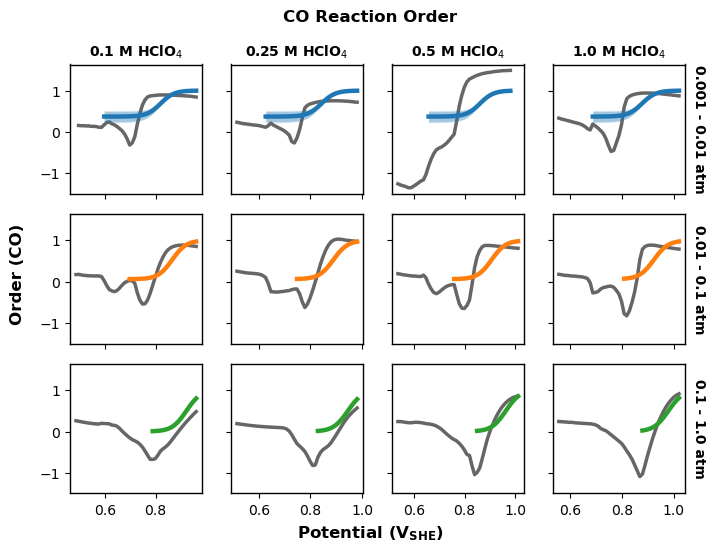

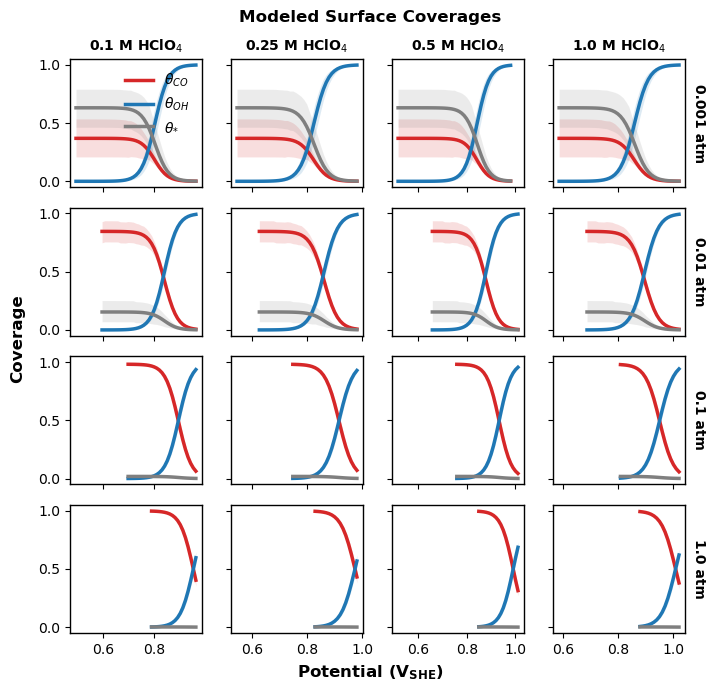

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# LH 2 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.18,31
,3000,0,0.18,31
,3000,0,0.16,103
,3000,0,0.16,63


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   796.47    37.64
p_loo       17.41        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



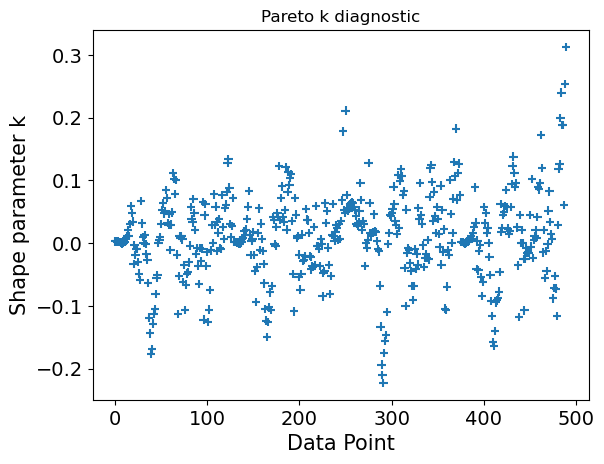

In [6]:
with pm.Model() as LH_2_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.8, sigma=0.05)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact4_0 = pm.Normal('Gact4_0', mu=1.2, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    Gact4 = Gact4_0 - beta_4*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k4 = np.log(kb_J*T/h) - Gact4/(kb_eV*T)
    log_k_minus4 = log_k4 - log_K4

    K1_Pco = pt.exp(log_K1 + np.log(P_CO_in))
    A = 1.0 + K1_Pco
    B = pt.exp(log_k_minus4 + np.log(C_H_in))
    C = pt.exp(log_k2) * K1_Pco
    k4_lin = pt.exp(log_k4)
    a_quad = A * C
    b_quad = (A * B) + k4_lin - C
    c_quad = -B
    theta_empty_lin = (-b_quad + pt.sqrt(b_quad**2 - 4 * a_quad * c_quad)) / (2 * a_quad)
    log_theta = pt.log(theta_empty_lin)
    log_theta_CO = log_K1 + np.log(P_CO_in) + log_theta
    log_denominator = pt.logsumexp(pt.stack([log_k_minus4 + np.log(C_H_in), log_k2 + log_theta_CO]), axis=0)
    log_theta_OH = log_k4 + log_theta - log_denominator

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', theta_empty_lin)

    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2_4, loo_LH_2_4 = fit_and_evaluate(LH_2_4)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.037  0.005  -0.045   -0.028      0.000    0.000    1619.0    1729.0    1.0
deltaG4_0   0.917  0.003   0.912    0.921      0.000    0.000    2827.0    2379.0    1.0
Gact2_0     0.670  0.003   0.665    0.675      0.000    0.000    1726.0    1734.0    1.0
Gact4_0     1.169  0.029   1.115    1.222      0.001    0.001     504.0     808.0    1.0
beta_4      0.520  0.032   0.460    0.577      0.001    0.001     485.0     810.0    1.0
sigma_rel   0.231  0.019   0.193    0.265      0.000    0.000    2711.0    2742.0    1.0
sigma_base  0.006  0.001   0.004    0.007      0.000    0.000    2535.0    2689.0    1.0
exponent    0.957  0.075   0.826    1.098      0.002    0.001    1651.0    2341.0    1.0


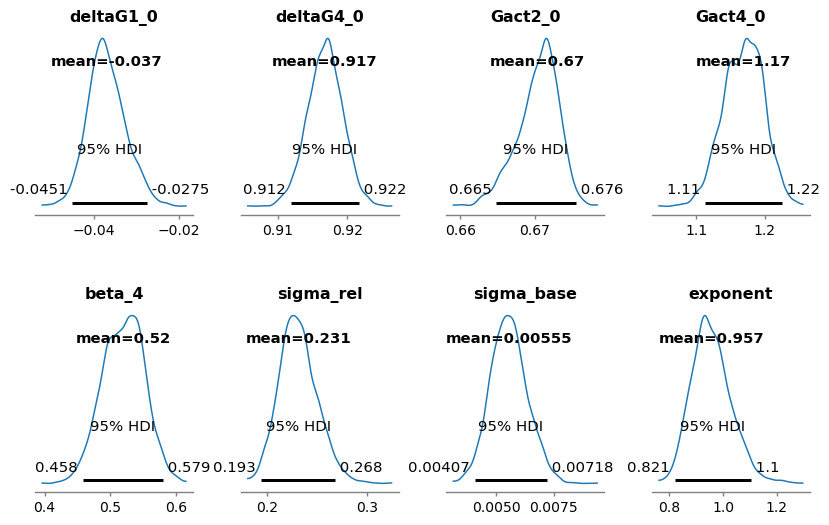

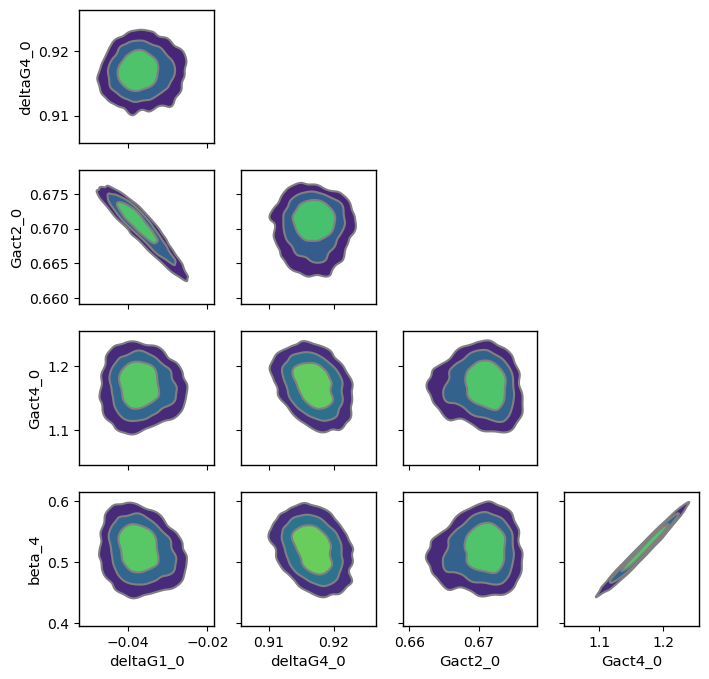

Sampling: [rate]


rate: 0.872


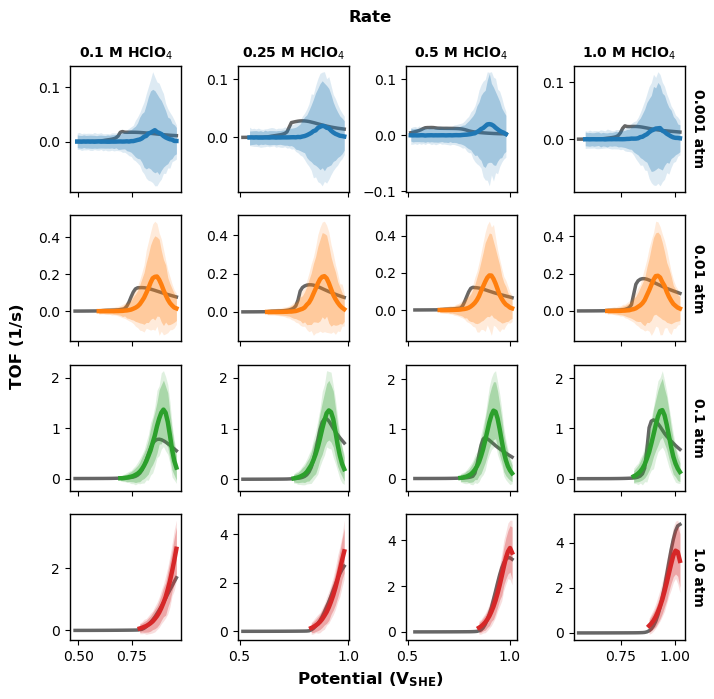

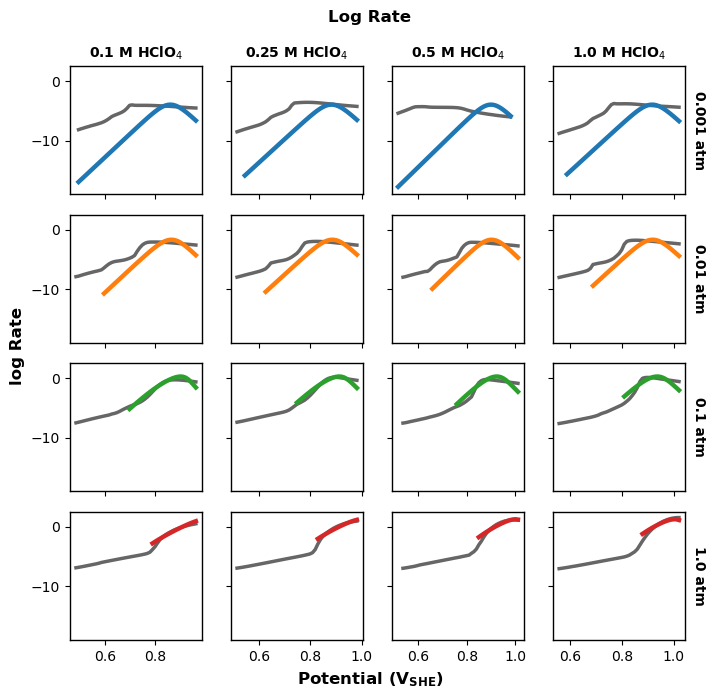

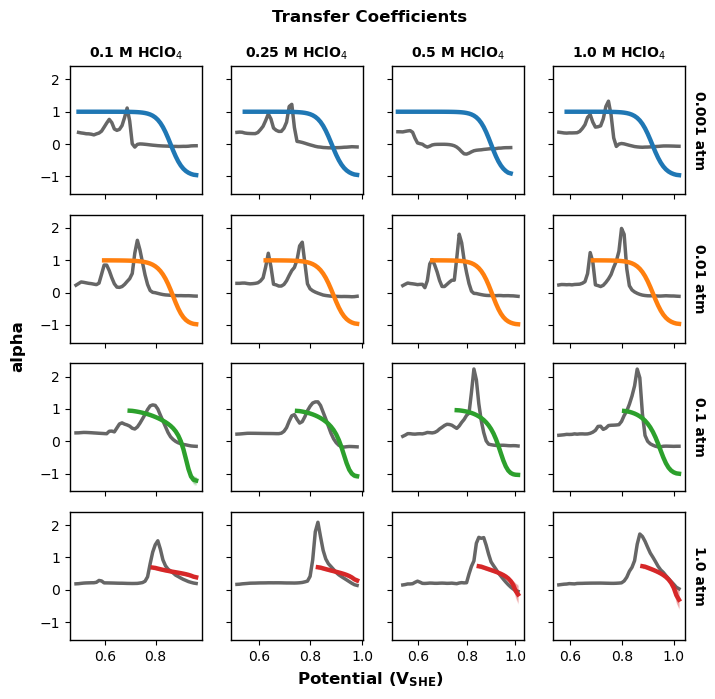

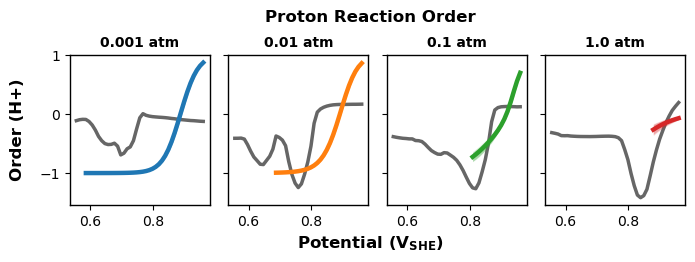

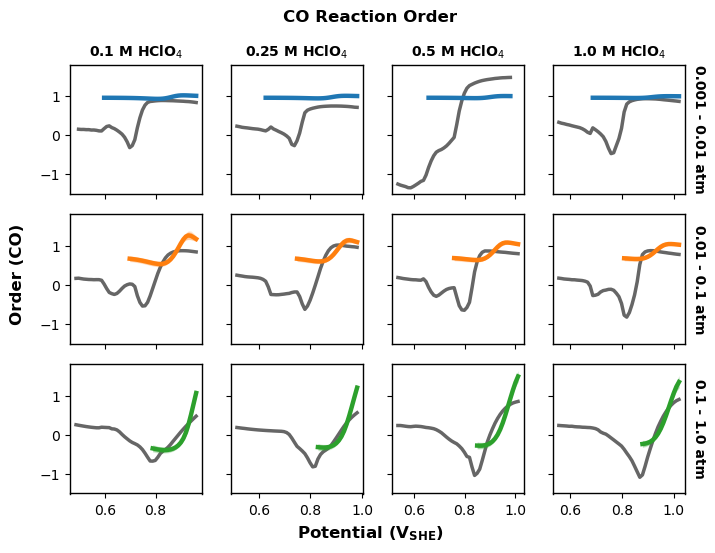

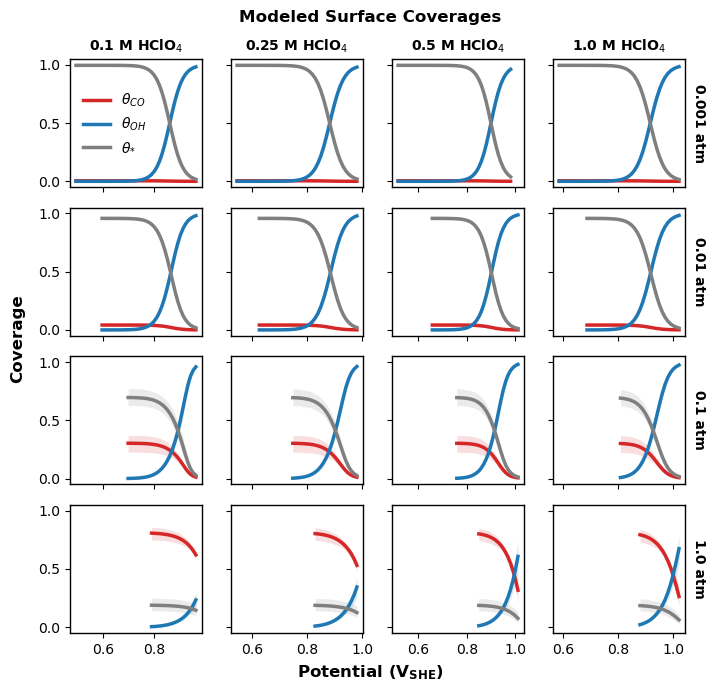

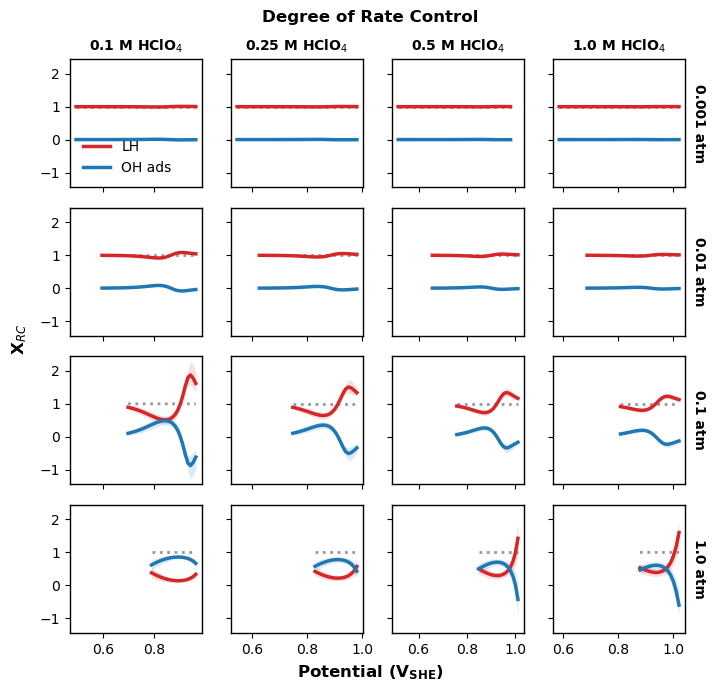

In [7]:
ppc_LH_2_4 = plot_posteriors(trace_LH_2_4, LH_2_4)
plot_model_fits(trace_LH_2_4, ppc_LH_2_4); plot_coverages(trace_LH_2_4)
plot_drc(LH_2_4, trace_LH_2_4, perturb_vars=['Gact2_0', 'Gact4_0'], perturb_labels=['LH', 'OH ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact4_0': 'Gact'})

# LH PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.17,63
,3000,0,0.18,15
,3000,0,0.17,27
,3000,0,0.16,95


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   947.38    37.37
p_loo        8.26        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



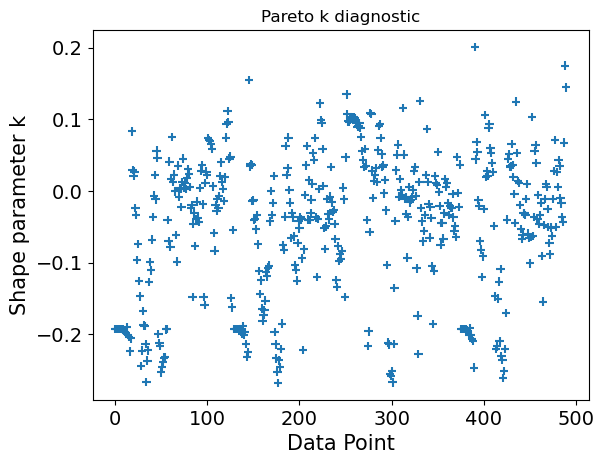

In [8]:
with pm.Model() as LH_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_PCT, loo_LH_PCT = fit_and_evaluate(LH_PCT)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.091  0.002  -0.096   -0.087      0.000    0.000    1988.0    2315.0    1.0
deltaG4_0   0.616  0.011   0.597    0.636      0.000    0.000     958.0    1320.0    1.0
Gact2_0     0.944  0.010   0.926    0.963      0.000    0.000    1008.0    1275.0    1.0
beta_2      0.931  0.027   0.880    0.977      0.001    0.001    1285.0    1418.0    1.0
q           0.711  0.011   0.692    0.731      0.000    0.000     950.0    1194.0    1.0
sigma_rel   0.289  0.027   0.244    0.343      0.000    0.000    3079.0    2678.0    1.0
sigma_base  0.005  0.000   0.005    0.006      0.000    0.000    4051.0    2424.0    1.0
exponent    1.719  0.087   1.556    1.873      0.002    0.001    2902.0    2469.0    1.0


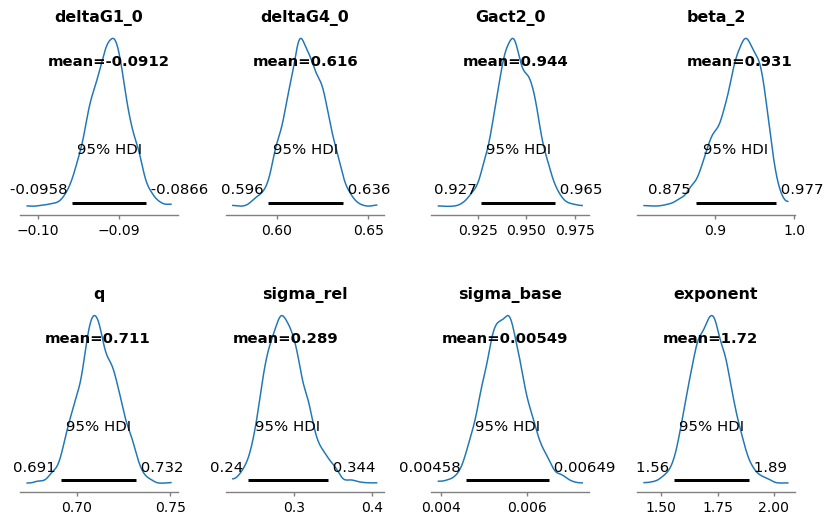

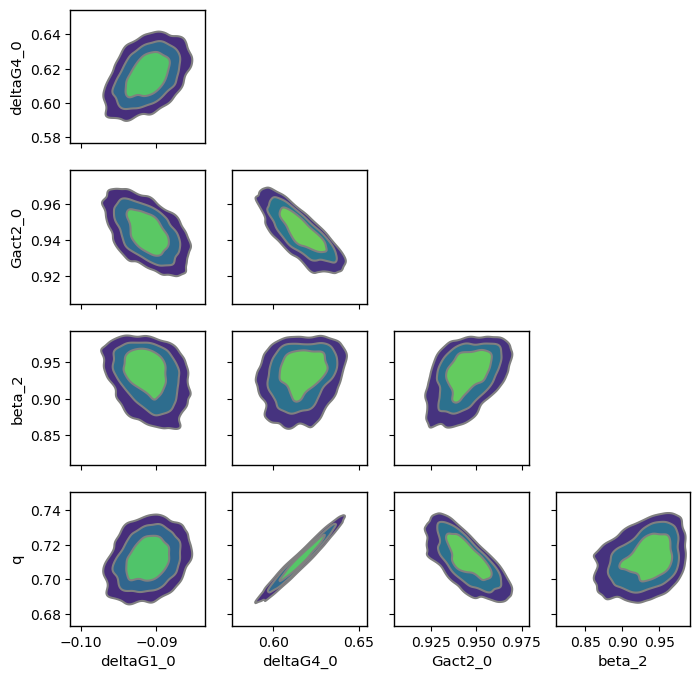

Sampling: [rate]


rate: 0.821


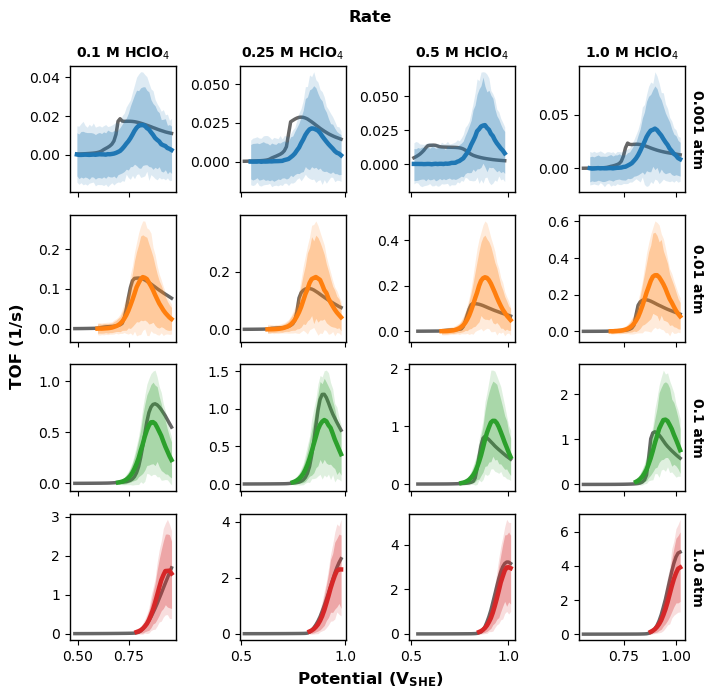

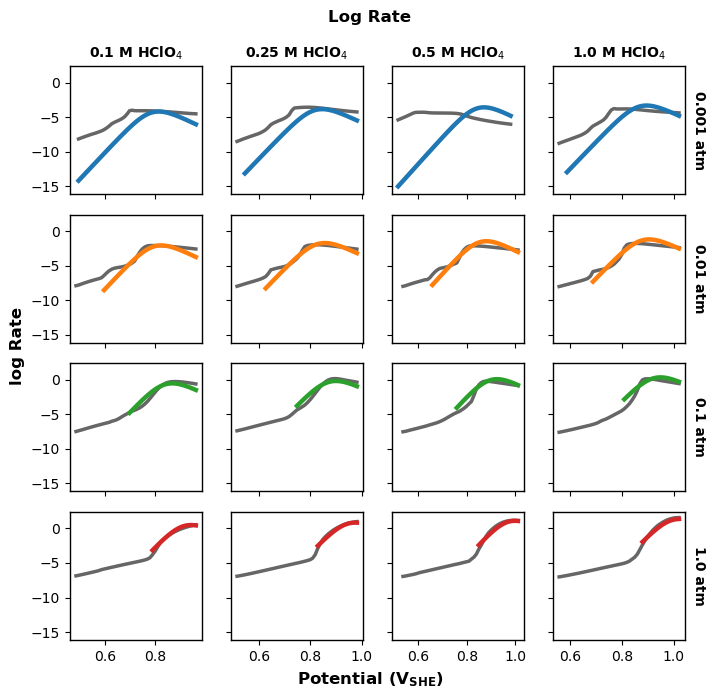

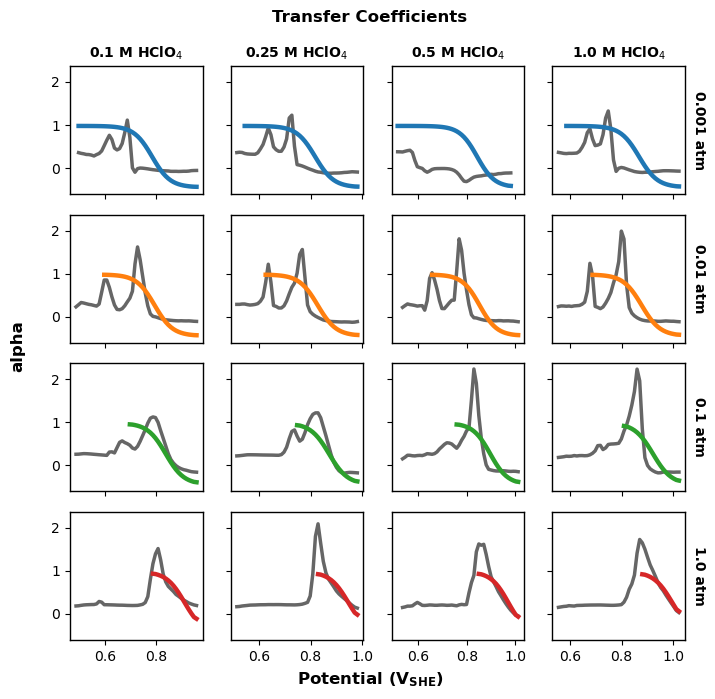

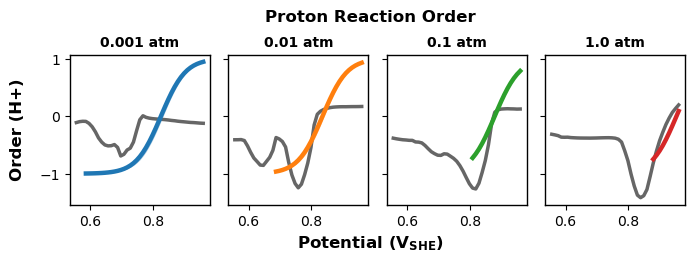

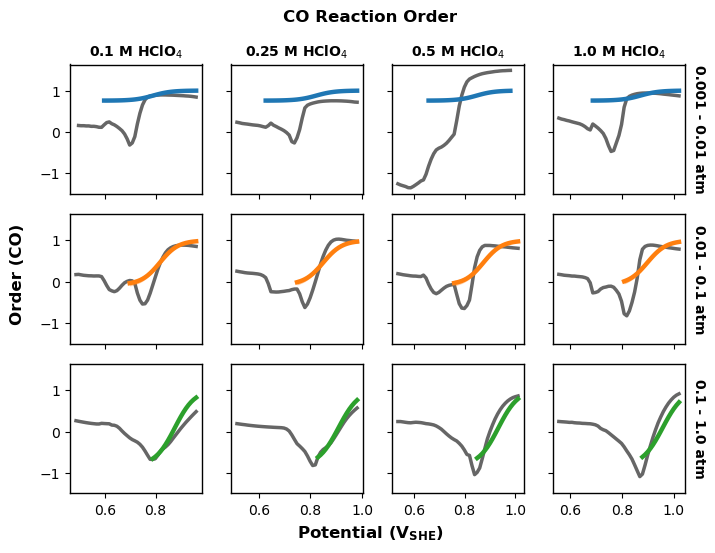

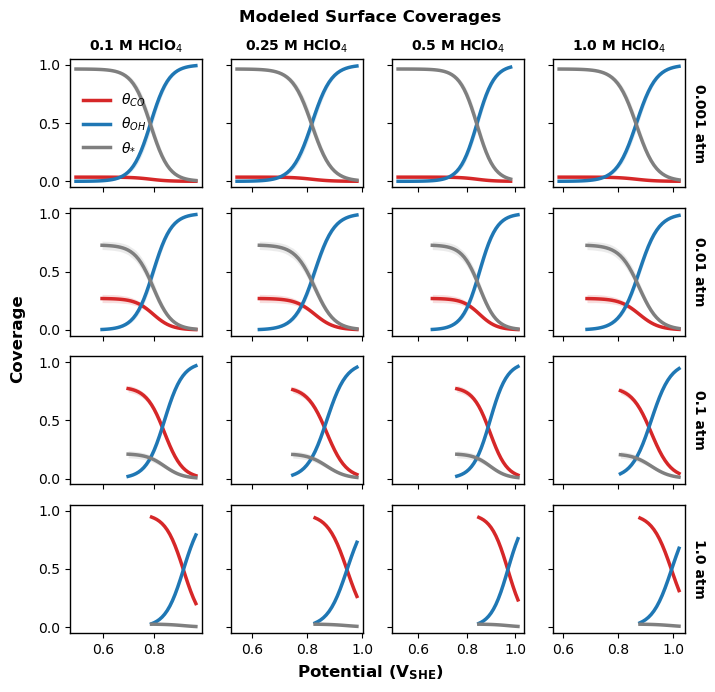

In [9]:
ppc_LH_PCT = plot_posteriors(trace_LH_PCT, LH_PCT)
plot_model_fits(trace_LH_PCT, ppc_LH_PCT); plot_coverages(trace_LH_PCT)

# Comparison

        rank    elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
LH_PCT     0  947.376605   8.264153    0.000000  8.181227e-01  37.366990   0.000000    False   log
ER_2       1  861.295516  11.044364   86.081089  1.818773e-01  42.339304  18.136940    False   log
LH_2_4     2  796.468467  17.414575  150.908139  2.351078e-11  37.639651  17.464344    False   log
LH_2       3  774.016719  11.857480  173.359887  0.000000e+00  41.215688  17.628944    False   log


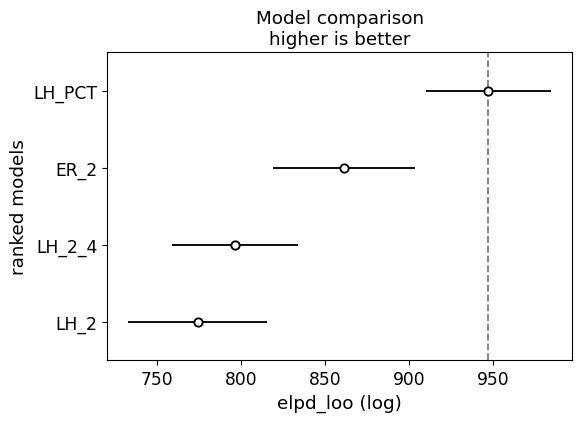

In [21]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2, 
    "LH_2_4": loo_LH_2_4,
    "LH_PCT": loo_LH_PCT,

}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()